<div align="center">

#####

#Teoría de Circuitos 2

##Trabajo Práctico N°3

**Estudiante:** Nahir Lewartowski

</div>

---


##Función transferencia mediante método Storch

$Q_n(s) = (2n-1) \cdot Q_{n-1}(s) + s^2 \cdot Q_{n-2}(s)$

$Q_0(s) = 1$

$Q_1(s) = s + 1$

$Q_2(s)= 3 \cdot (s + 1) + s^2 = s^2 + 3s + 3$

$Q_3(s)= 5 \cdot (s^2 + 3s + 3) + s^2 \cdot (s+1) = s^3 + 6 s^2 + 15 s + 15$

$Q_4(s) = 7 \cdot (s^3 + 6s^2 + 15s + 15) + s^2 \cdot (s^2 + 3s + 3) = s^4 + 10s^3 + 45s^2 + 105s + 105$

$\displaystyle T_2(s) = \frac{3}{s^2 + 3s + 3} $

$\displaystyle T_3(s) = \frac{15}{s^3 + 6 s^2 + 15 s + 15}$

$\displaystyle T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}$

Estableciendo $\alpha_{max}=1dB$, verifico cuál de las transferencias cumple el requisito:

Primero reemplazo $s = j\omega$, luego separo la parte real de la imaginaria y calculo el módulo.

$\displaystyle|T_2(j\omega)|_{\omega=1} = \frac{3}{\sqrt{(3 - \omega^2)^2 + (3\omega)^2}}=\frac {3}{\sqrt{13}}$

$\alpha(1) = -20 \log_{10}(\frac {3}{\sqrt{13}}) \approx 1.59\text{ dB}$

$T_2$ no cumple, se descarta para este diseño.

$\displaystyle|T_3(j\omega)|_{\omega=1} = \frac{15}{\sqrt{(-6\omega^2+15)^2 + (-\omega^3+15\omega)^2}}=0.9013$

$\alpha(1) = -20 \log_{10}(0.9013) \approx 0.9\text{ dB}$

$\displaystyle|T_3(j\omega)|_{\omega=2.5} = \frac{15}{\sqrt{(-6\omega^2+15)^2 + (-\omega^3+15\omega)^2}}=0.48$

$\alpha(2.5) = -20 \log_{10}(0.48) \approx 6.37\text{ dB}$

$T_2$ cumple tanto la condición $\alpha_{\omega=1} < 1\text{ dB}$ como $\alpha_{\omega=2.5} > 5\text{ dB}$

##Simulación en Python

In [3]:
!pip install -q pytc2

In [2]:
from pytc2.sistemas_lineales import pretty_print_lti

# Orden 2
num2 = [3]
den2 = [1, 3, 3]

# Orden 3
num3 = [15]
den3 = [1, 6, 15, 15]

# Orden 4
num4 = [105]
den4 = [1, 10, 45, 105, 105]

print("Transferencia de orden N=2:")
pretty_print_lti(num2, den2)

print("\nTransferencia de orden N=3:")
pretty_print_lti(num3, den3)

print("\nTransferencia de orden N=4:")
pretty_print_lti(num4, den4)

Transferencia de orden N=2:


<IPython.core.display.Math object>


Transferencia de orden N=3:


<IPython.core.display.Math object>


Transferencia de orden N=4:


<IPython.core.display.Math object>

##Retardo de grupo

$\displaystyle D(\omega) = -\frac{\partial \measuredangle T}{\partial \omega}$

$\displaystyle T_3(j\omega) = \frac{15}{(-6\omega^2+15) + j(-\omega^3+15\omega)}$

$\displaystyle D(\omega) = \frac{(-6\omega^2+15)(-3\omega^2+15) - (-\omega^3+15\omega)(-12\omega)}{(-6\omega^2+15)^2 + (-\omega^3+15\omega)^2}$

$\displaystyle D(\omega) = \frac{6\omega^4+45\omega^2+225}{\omega^6+6\omega^4+45\omega^2+225}$

$D(0) = \frac{225}{225} = 1 \,seg$

$\displaystyle D(2.5) = \frac{740.625}{984.765625} = 0.752 \,seg$

Error (\%) $= \frac{D(2.5) - D(0)}{D(0)} \cdot 100 = \frac{0.752 - 1}{1} \cdot 100 \approx -24.8 \%$


##Sintetizado del circuito

$\displaystyle T_3(s) = \frac{2.32}{s + 2.32} \cdot \frac{6.45}{s^2 + 3.68s + 6.45}$

Del primer bloque:

$\omega_c = \frac{1}{RC} = 2.32$

Fijando $R=1Ω$, $C = \frac{1}{2.32} \approx 0.431\text{ F}$

Del segundo bloque:

$\omega_o = \frac{1}{\sqrt{R_1 R_2 C_1 C_2}} = 2.54$

$\frac{\omega_o}{Q} = \frac{1}{R_1 C_1} + \frac{1}{R_2 C_1} = 3.68$

Fijando $R_1 = R_2 = 1\Omega$, $C_1 = \frac{2}{3.68} \approx 0.543\text{ F}$ y $C_2 = \frac{1}{6.45 \cdot 0.543} \approx 0.285\text{ F}$

Circuito normalizado:

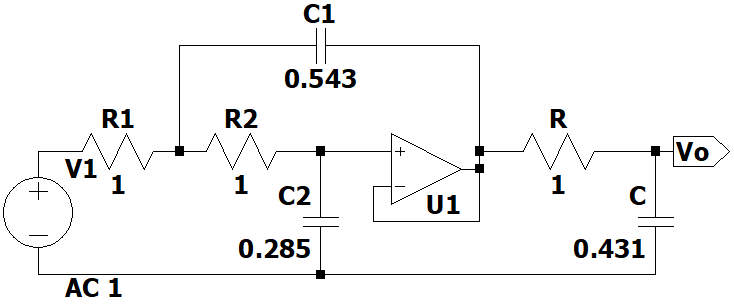

##Desnormalización

$\displaystyle \Omega_\omega = \frac{D_{norm}(0)}{D_{real}(0)} = \frac{1}{200 \times 10^{-6}} = 5000 \text{ rad/s}$

Fijando las resistencias a $10kΩ$:

$\displaystyle C_{real} = \frac{C_{norm}}{\Omega_\omega \cdot \Omega_z} = \frac{C_{norm}}{5000 \cdot 10000} = C_{norm} \cdot 20 \text{ nF}$

$C_{1\_real} = 0.543 \cdot 20 \text{ nF} = 10.86 \text{ nF}$

$C_{2\_real} = 0.285 \cdot 20 \text{ nF} = 5.7 \text{ nF}$

$C_{real} = 0.431 \cdot 20 \text{ nF} = 8.62 \text{ nF}$

$f_p = \frac{5000}{2\pi} \approx 795.7 \text{ Hz}$

$f_s = \frac{12500}{2\pi} \approx 1989.4 \text{ Hz}$

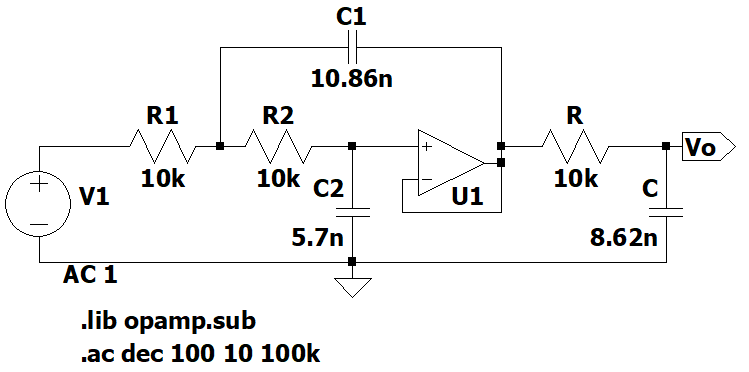

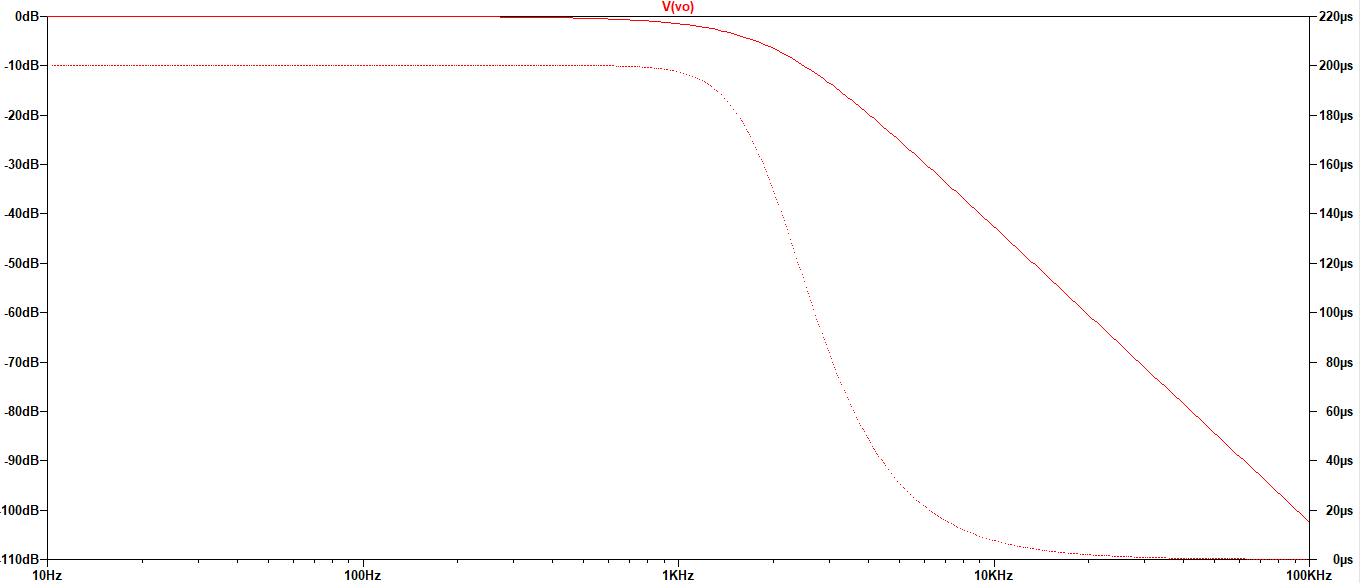

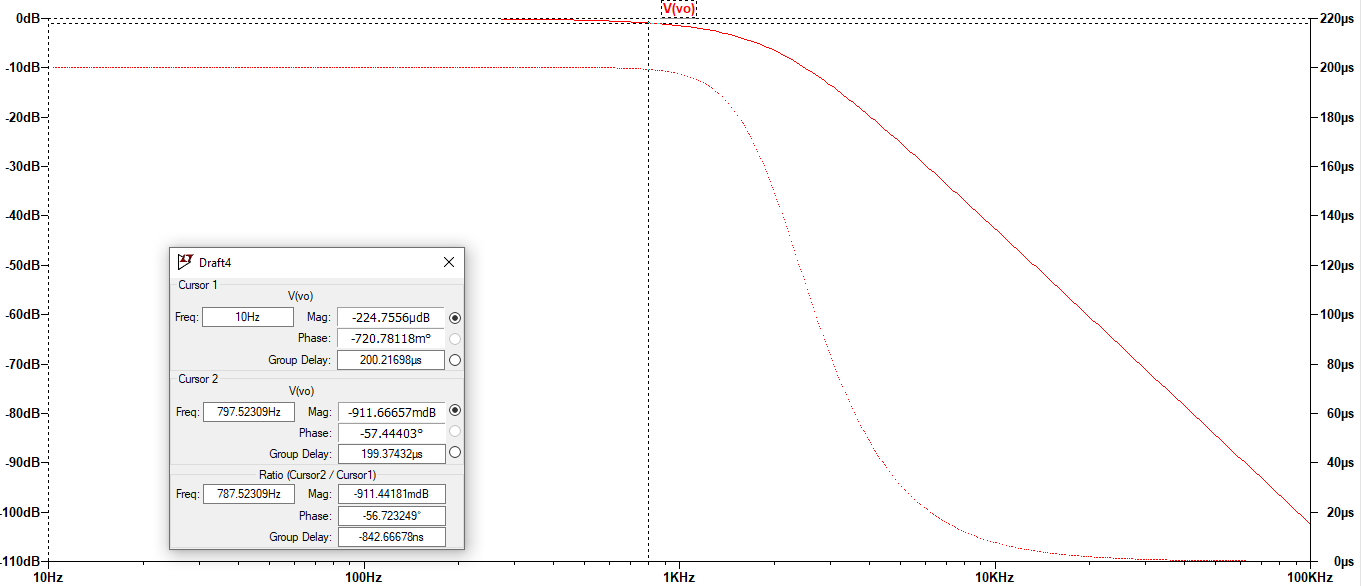

A bajas frecuencias, $D = 200.21698μs$

Para el límite de la banda de paso (aproximadamente $797.5\text{ Hz}$) $D = 199.37432μs$ y la magnitud es de $-0.91\text{ dB}$.

$\Delta D = -842.66678ns$

Verificación gráfica de la atenuación para $\omega_s$:

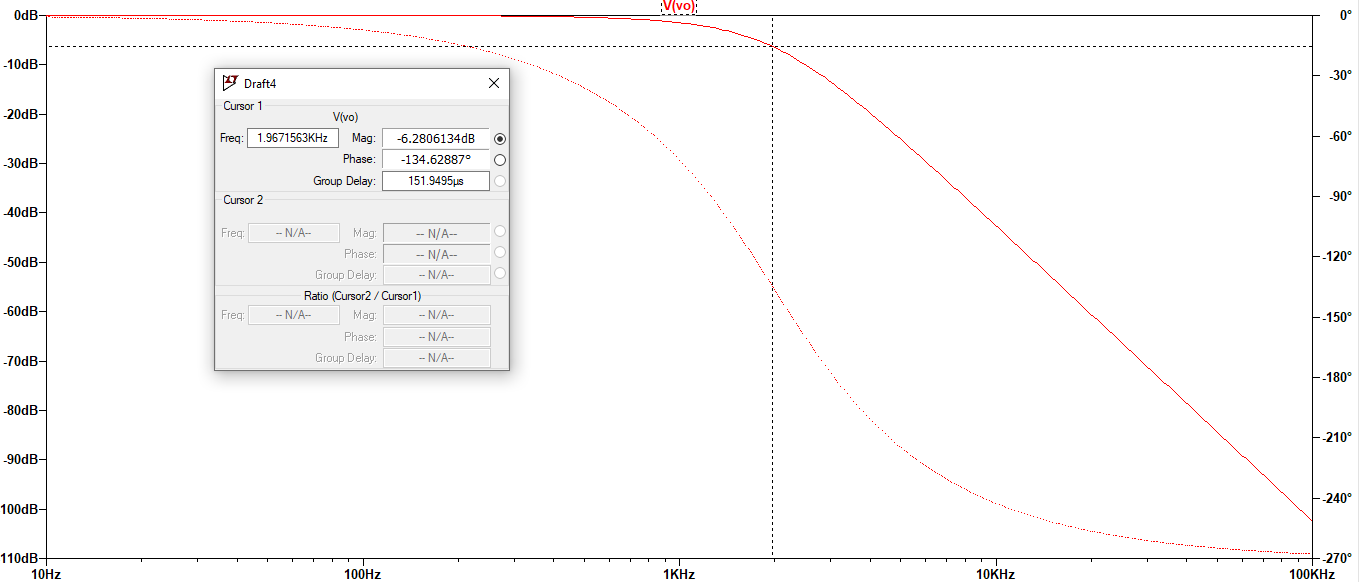

##Conclusión

Los cálculos y la simulación coinciden con las condiciones de diseño, para $\omega_p$ la atenuación es menor a 1dB, mientras que para $\omega_s$ es mayor que los 5dB establecidos. También se confirma que la diferencia en el retardo de grupo es menor a $1\mu s$.